In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
import pandas as pd
df = pd.read_csv('/content/Kelas D_Happiness and Satisfaction.csv', sep=';', decimal=',')

In [60]:
# Data Set
df

,Country,adjusted_satisfaction (0-100),avg_satisfaction (0-10),std_satisfaction,avg_income (&),median_income (&),income_inequality,Region,Happy Score (0-10),GDP,country.1
0,Armenia,37,4.9,2.42,2096.76,1731.506667,31.445556,'Central and Eastern Europe',4.350,0.76821,Armenia
1,Angola,26,4.3,3.19,1448.88,1044.240000,42.720000,'Sub-Saharan Africa',4.033,0.75778,Angola
2,Argentina,60,7.1,1.91,7101.12,5109.400000,45.475556,'Latin America and Caribbean',6.574,1.05351,Argentina
3,Austria,59,7.2,2.11,19457.04,16879.620000,30.296250,'Western Europe',7.200,1.33723,Austria
4,Australia,65,7.6,1.80,19917.00,15846.060000,35.285000,'Australia and New Zealand',7.284,1.33358,Australia
...,...,...,...,...,...,...,...,...,...,...,...
106,Uruguay,58,7.0,2.13,7544.40,5269.226667,45.014444,'Latin America and Caribbean',6.485,1.06166,Uruguay
107,Vietnam,53,6.1,1.77,2231.40,1643.580000,39.242500,'Southeastern Asia',5.360,0.63216,Vietnam
108,South Africa,49,6.3,2.47,3889.32,1506.400000,63.726667,'Sub-Saharan Africa',4.642,0.92049,South Africa
109,Zambia,37,5.0,2.61,956.76,510.060000,55.120000,'Sub-Saharan Africa',5.129,0.47038,Zambia


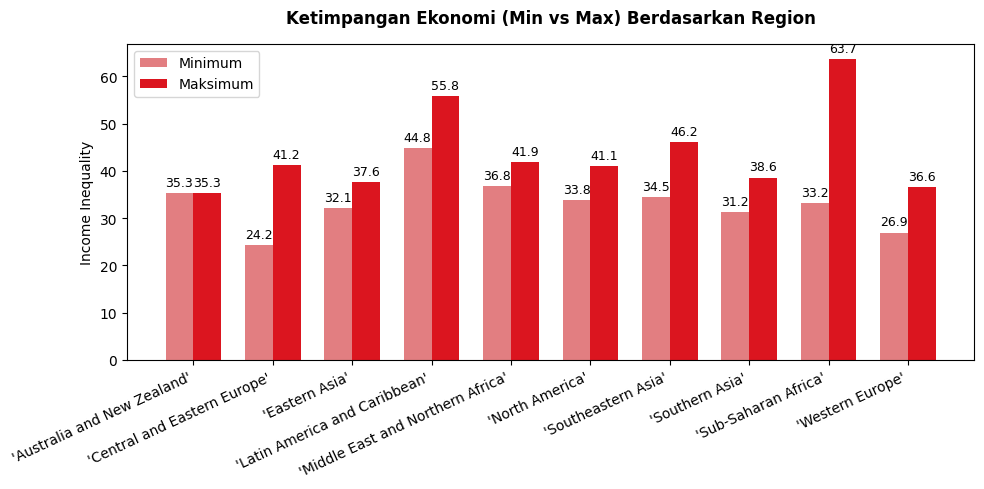

In [61]:
# Nilai min dan max per wilayah
stats = (
    df.groupby("Region")["income_inequality"]
    .agg(["min", "max"])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
pos = np.arange(len(stats["Region"]))
lebar = 0.35

# Bar chart
bar1 = ax.bar(pos - lebar / 2, stats["min"], lebar, label="Minimum", color="#E27E81")
bar2 = ax.bar(pos + lebar / 2, stats["max"], lebar, label="Maksimum", color="#DB151F")
ax.bar_label(bar1, fmt='%.1f', padding=3, fontsize=9)
ax.bar_label(bar2, fmt='%.1f', padding=3, fontsize=9)
ax.set_title("Ketimpangan Ekonomi (Min vs Max) Berdasarkan Region", pad=15, weight='bold')
ax.set_ylabel("Income Inequality")
ax.set_xticks(pos)
ax.set_xticklabels(stats["Region"], rotation=25, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

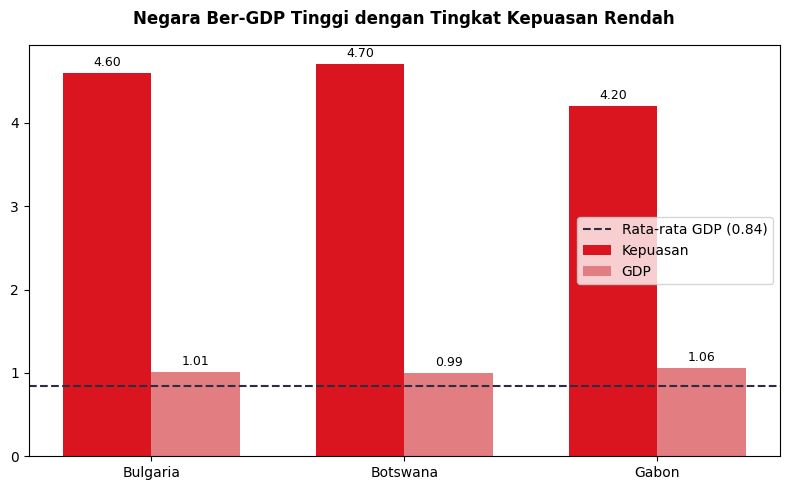

In [62]:
# Filter negara yang tingkat kepuasannya di bawah 5.0 dan GDP di atas rata-rata
rata_gdp = df["GDP"].mean()
kondisi = (df["avg_satisfaction (0-10)"] < 5.0) & (df["GDP"] > rata_gdp)
target_negara = df[kondisi]

fig, ax = plt.subplots(figsize=(8, 5))
pos = np.arange(len(target_negara["Country"]))
lebar = 0.35

# Bar chart
bar_sat = ax.bar(pos - lebar / 2, target_negara["avg_satisfaction (0-10)"], lebar, label="Kepuasan", color="#DB151F")
bar_gdp = ax.bar(pos + lebar / 2, target_negara["GDP"], lebar, label="GDP", color="#E27E81")
ax.bar_label(bar_sat, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bar_gdp, fmt='%.2f', padding=3, fontsize=9)

ax.axhline(rata_gdp, color="#2b2d42", linestyle="--", label=f"Rata-rata GDP ({rata_gdp:.2f})")

ax.set_title("Negara Ber-GDP Tinggi dengan Tingkat Kepuasan Rendah", pad=15, weight='bold')
ax.set_xticks(pos)
ax.set_xticklabels(target_negara["Country"])
ax.legend()

plt.tight_layout()
plt.show()

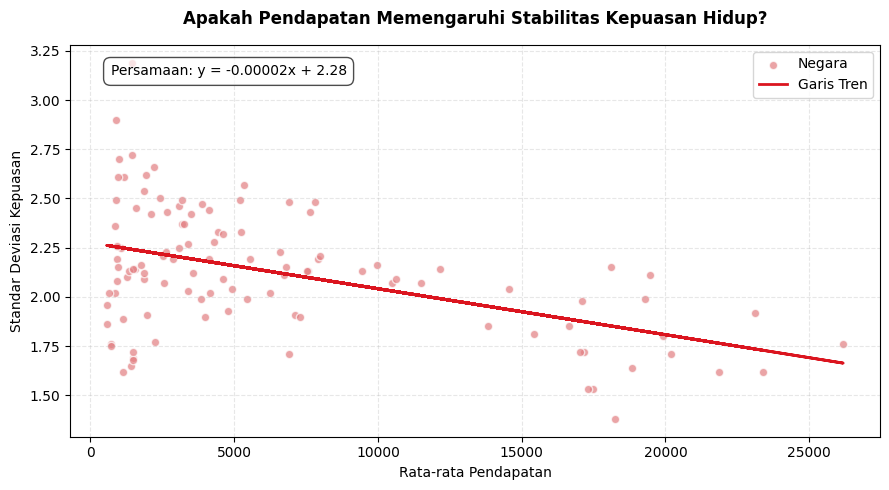

In [63]:
#Analisis hubungan antara stabilitas jawaban kepuasan dengan tingkat pendapatan masyarakat
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df["avg_income (&)"], df["std_satisfaction"], color="#E27E81", alpha=0.7, edgecolors="w", label="Negara")

m, c = np.polyfit(df["avg_income (&)"], df["std_satisfaction"], 1)
ax.plot(df["avg_income (&)"], m * df["avg_income (&)"] + c, color="#DB151F", linewidth=2, label="Garis Tren")

# Rumus persamaan garis tren dan scatter plot
teks_tren = f'Persamaan: y = {m:.5f}x + {c:.2f}'
ax.text(0.05, 0.95, teks_tren, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))

ax.set_title("Apakah Pendapatan Memengaruhi Stabilitas Kepuasan Hidup?", pad=15, weight='bold')
ax.set_xlabel("Rata-rata Pendapatan")
ax.set_ylabel("Standar Deviasi Kepuasan")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

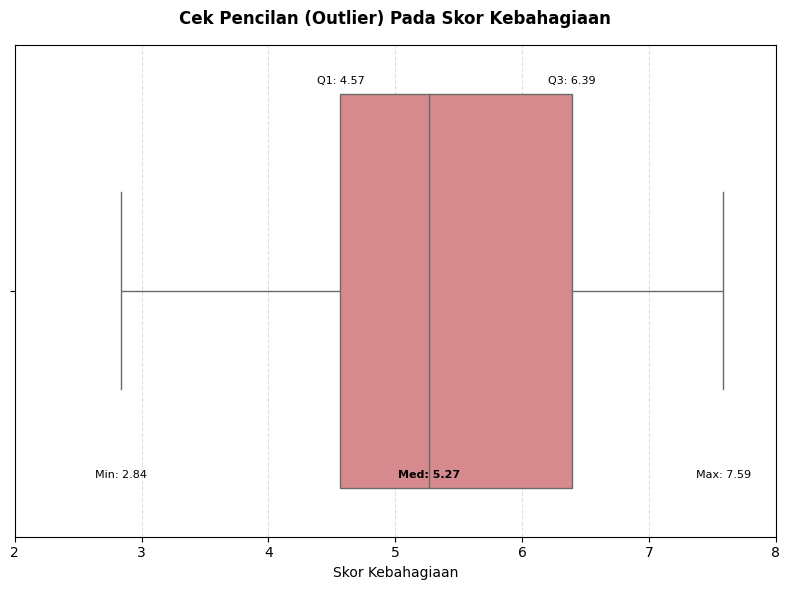

In [64]:
# Pencilan bawah (outlier) pada skor kebahagiaan
fig, ax = plt.subplots(figsize=(8,6))

sns.boxplot(x=df["Happy Score (0-10)"], color="#E27E81", ax=ax, flierprops={"markerfacecolor": "#DB151F", "marker": "o"})

skor = df["Happy Score (0-10)"].dropna()
v_min, q1, median, q3, v_max = skor.min(), skor.quantile(0.25), skor.median(), skor.quantile(0.75), skor.max()

# Box plot
ax.text(v_min, 0.38, f'Min: {v_min:.2f}', ha='center', fontsize=8, color='black')
ax.text(q1, -0.42, f'Q1: {q1:.2f}', ha='center', fontsize=8, color='black')
ax.text(median, 0.38, f'Med: {median:.2f}', ha='center', fontsize=8, color='black', weight='bold')
ax.text(q3, -0.42, f'Q3: {q3:.2f}', ha='center', fontsize=8, color='black')
ax.text(v_max, 0.38, f'Max: {v_max:.2f}', ha='center', fontsize=8, color='black')

ax.set_title("Cek Pencilan (Outlier) Pada Skor Kebahagiaan", pad=15, weight='bold')
ax.set_xlabel("Skor Kebahagiaan")
ax.set_xticks(range(2, 9))
ax.set_xticklabels(range(2, 9))
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

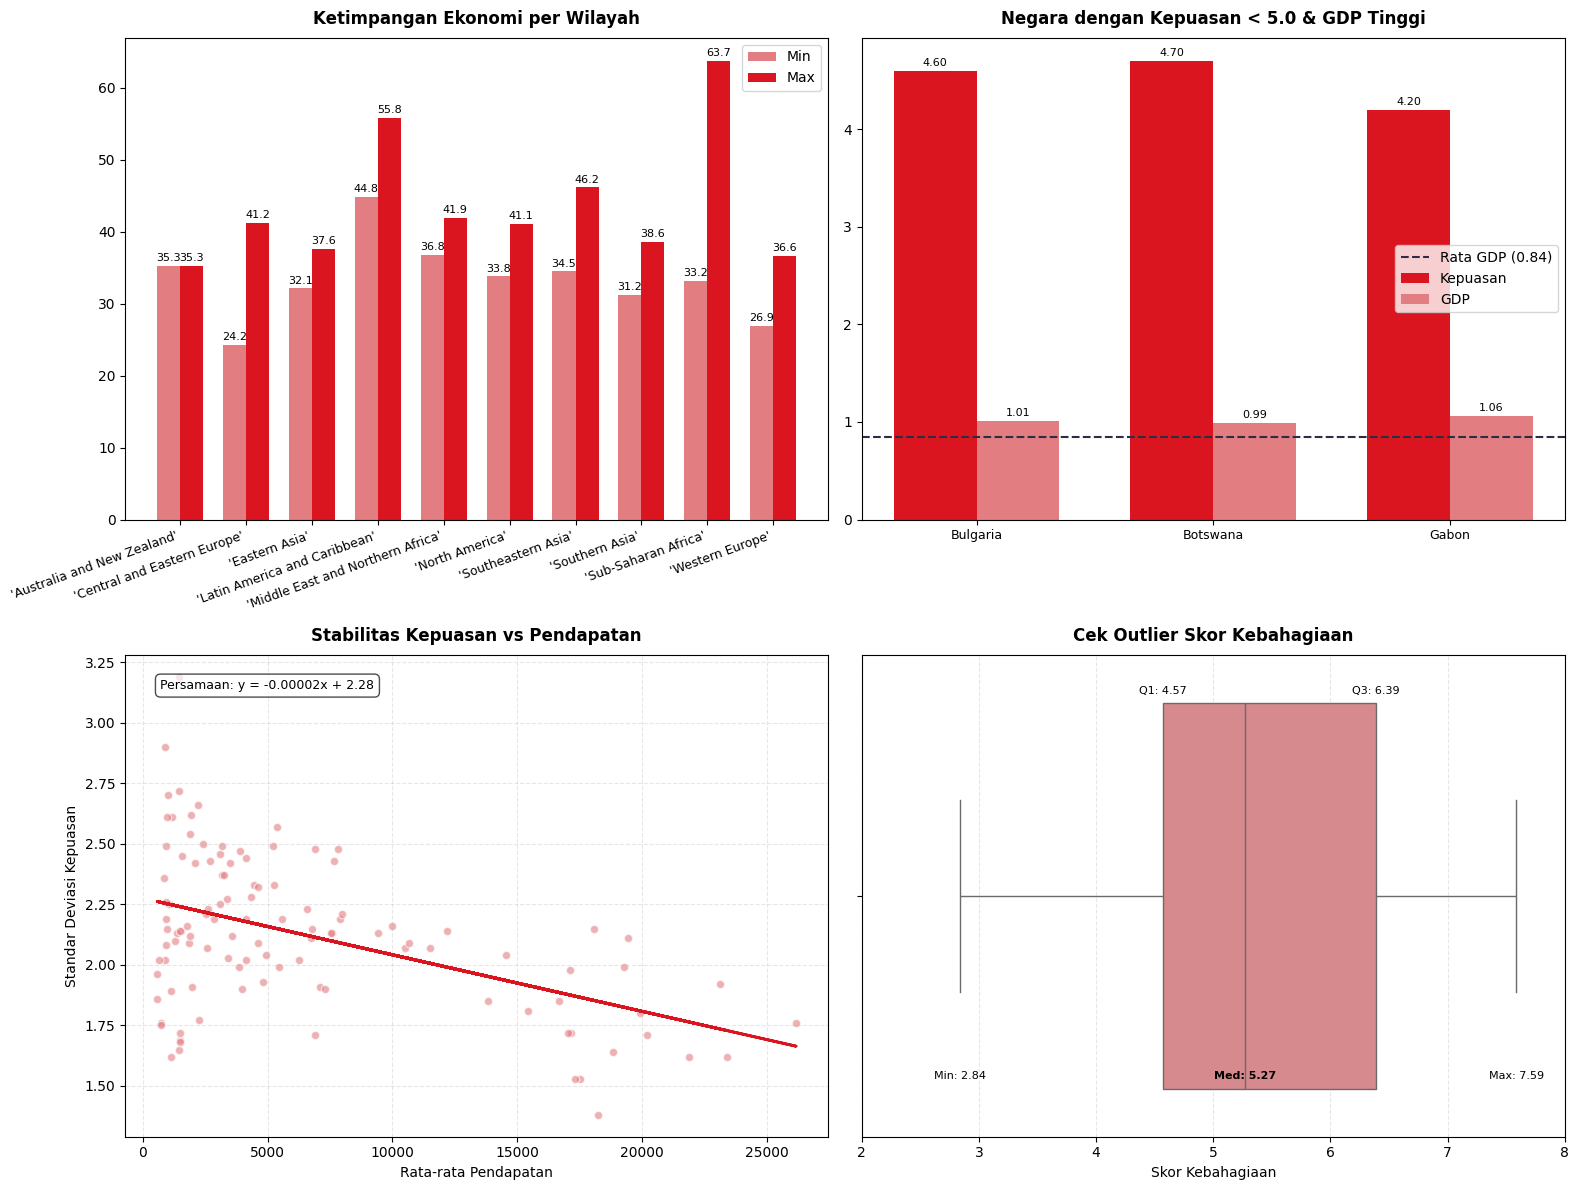

In [65]:
# --- PLOT GRID 2x2 ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# [0, 0] Kiri Atas: Grouped Bar (Ketimpangan Ekonomi)
stats = df.groupby("Region")["income_inequality"].agg(["min", "max"]).reset_index()
x1 = np.arange(len(stats["Region"]))
w1 = 0.35
g1_bar1 = axes[0, 0].bar(x1 - w1 / 2, stats["min"], w1, label="Min", color="#E27E81")
g1_bar2 = axes[0, 0].bar(x1 + w1 / 2, stats["max"], w1, label="Max", color="#DB151F")

axes[0, 0].bar_label(g1_bar1, fmt='%.1f', padding=2, fontsize=8)
axes[0, 0].bar_label(g1_bar2, fmt='%.1f', padding=2, fontsize=8)
axes[0, 0].set_title("Ketimpangan Ekonomi per Wilayah", weight='bold', pad=10)
axes[0, 0].set_xticks(x1)
axes[0, 0].set_xticklabels(stats["Region"], rotation=20, ha="right", fontsize=9)
axes[0, 0].legend()

# [0, 1] Kanan Atas: Bar Chart Kasus Negara (GDP Tinggi, Puas Rendah)
rata_gdp = df["GDP"].mean()
target = df[(df["avg_satisfaction (0-10)"] < 5.0) & (df["GDP"] > rata_gdp)]
x2 = np.arange(len(target["Country"]))
w2 = 0.35
g2_bar1 = axes[0, 1].bar(x2 - w2 / 2, target["avg_satisfaction (0-10)"], w2, label="Kepuasan", color="#DB151F")
g2_bar2 = axes[0, 1].bar(x2 + w2 / 2, target["GDP"], w2, label="GDP", color="#E27E81")

axes[0, 1].bar_label(g2_bar1, fmt='%.2f', padding=2, fontsize=8)
axes[0, 1].bar_label(g2_bar2, fmt='%.2f', padding=2, fontsize=8)
axes[0, 1].axhline(rata_gdp, color="#2b2d42", linestyle="--", label=f"Rata GDP ({rata_gdp:.2f})")
axes[0, 1].set_title("Negara dengan Kepuasan < 5.0 & GDP Tinggi", weight='bold', pad=10)
axes[0, 1].set_xticks(x2)
axes[0, 1].set_xticklabels(target["Country"], fontsize=9)
axes[0, 1].legend()

# [1, 0] Kiri Bawah: Scatter Plot (Kepuasan vs Pendapatan)
axes[1, 0].scatter(df["avg_income (&)"], df["std_satisfaction"], color="#E27E81", alpha=0.6, edgecolors="w")
m, c = np.polyfit(df["avg_income (&)"], df["std_satisfaction"], 1)
axes[1, 0].plot(df["avg_income (&)"], m * df["avg_income (&)"] + c, color="#DB151F", linewidth=2)

teks_tren_grid = f'Persamaan: y = {m:.5f}x + {c:.2f}'
axes[1, 0].text(0.05, 0.95, teks_tren_grid, transform=axes[1, 0].transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.7))
axes[1, 0].set_title("Stabilitas Kepuasan vs Pendapatan", weight='bold', pad=10)
axes[1, 0].set_xlabel("Rata-rata Pendapatan")
axes[1, 0].set_ylabel("Standar Deviasi Kepuasan")
axes[1, 0].grid(True, alpha=0.3, linestyle="--")

# [1, 1] Kanan Bawah: Boxplot (Skor Kebahagiaan)
sns.boxplot(x=df["Happy Score (0-10)"], color="#E27E81", ax=axes[1, 1], flierprops={"markerfacecolor": "#DB151F", "marker": "o"})

skor_grid = df["Happy Score (0-10)"].dropna()
v_min, q1, median, q3, v_max = skor_grid.min(), skor_grid.quantile(0.25), skor_grid.median(), skor_grid.quantile(0.75), skor_grid.max()

axes[1, 1].text(v_min, 0.38, f'Min: {v_min:.2f}', ha='center', fontsize=8)
axes[1, 1].text(q1, -0.42, f'Q1: {q1:.2f}', ha='center', fontsize=8)
axes[1, 1].text(median, 0.38, f'Med: {median:.2f}', ha='center', fontsize=8, weight='bold')
axes[1, 1].text(q3, -0.42, f'Q3: {q3:.2f}', ha='center', fontsize=8)
axes[1, 1].text(v_max, 0.38, f'Max: {v_max:.2f}', ha='center', fontsize=8)

axes[1, 1].set_title("Cek Outlier Skor Kebahagiaan", weight='bold', pad=10)
axes[1, 1].set_xlabel("Skor Kebahagiaan")
axes[1, 1].set_xticks(range(2, 9))
axes[1, 1].set_xticklabels(range(2, 9))
axes[1, 1].grid(axis="x", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()